In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp

In [2]:
from functions import fit, conversion, rotate_data

In [3]:
# input data: virtual meters for h and v
# h
# NEW FOR EACH RUN:
h1 = unp.uarray([-200,72], [5,5]) # coordinates in virt m 
h2 = unp.uarray([89,-74 ], [5,5])# virt m
# v 
#v1 = unp.uarray([22.02,-794.6], [10,10]) # virt m
#v2 = unp.uarray([-16.84,-126.1], [10,10]) # virt m

print(conversion(h1,h2))

0.1424+/-0.0031


In [5]:
test = np.loadtxt('m9_tos/m9_p0.txt', skiprows=2, unpack=True)
test.shape

(3, 1845)

T_far =  377.71+/-0.13


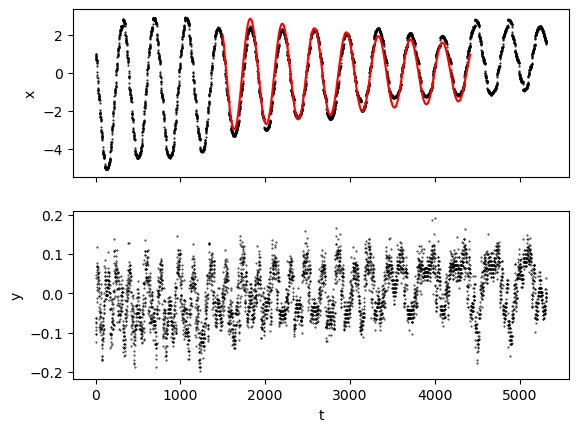

T_near =  377.56+/-0.11


In [6]:
#get period T0 far
Tf =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_p0.txt', skiprows=2, unpack=True), cutoff=500, cutoffend=-1)[2]
wf = fit(*np.loadtxt('m9_tos/m9_p0.txt', skiprows=2, unpack=True), cutoff=500, cutoffend=-1)[2]
print('T_far = ', Tf)
#near: 90min meas
cut1 = 1500
cut2 = -900
Tn =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_n.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2, plot=True)[2]
wn = fit(*np.loadtxt('m9_tos/m9_n.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2)[2]
print('T_near = ', Tn)

In [7]:
# G tos

# laser meas
L =  unp.uarray(4.321, 0.001) #m
    
#measured:
M = unp.uarray(1.5,0.01) 
#technical drawing
m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

#I = m*l**2/2 #kg m^2, using MIT estimated formula
l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
#l=unp.uarray(0.12, 0.001)
rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
#I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
I = m*l**2/2



#values:
rm = l/2
rM = ufloat(0.146,0.002)
r = rM-rm



#calc
Cn = -M*m*(3 * rm**2 * rM**2 -r**2 * rm * rM)/r**5
#Cn = 2 * M * m * rm * rM / r**3


G = I * (wn**2 - wf**2) /Cn

print(G)

(-6+/-6)e-11


## compare zero measurements

In [95]:
# compare all T0 
T2 = 2*np.pi/fit(*np.loadtxt('trash/meas2/zero.txt', skiprows=2, unpack=True), cutoff=500, cutoffend=-1)[2]
T5 =  2*np.pi/fit(*np.loadtxt('m5/m5_p0.txt', skiprows=2, unpack=True), cutoff=500, cutoffend=-1)[2]
T7 =  2*np.pi/fit(*np.loadtxt('m7/m7_p0.txt', skiprows=2, unpack=True), cutoff=500, cutoffend=-1)[2]
T9 =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_p0.txt', skiprows=2, unpack=True), cutoff=500, cutoffend=-1)[2]
print(T2)
print(T5)
print(T7)
print(T9)
print('argument for new zero measurement for each run')

379.553+/-0.021
377.09+/-0.06
377.328+/-0.016
377.71+/-0.13
argument for new zero measurement for each run


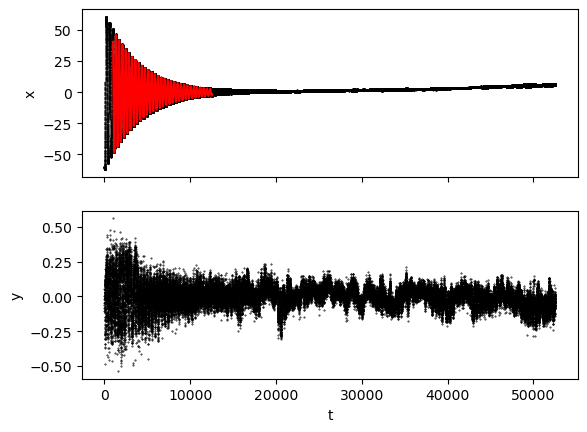

378.1005+/-0.0025 if cut 10000 to 40000 from end


In [88]:
#night measurement
T5_night =  2*np.pi/fit(*np.loadtxt('m5/m5_p0_nacht.txt', skiprows=2, unpack=True), cutoff=1000, cutoffend=-40000, plot=True)[2]
print(T5_night, 'if cut 10000 to 40000 from end')

## time of swing #2 2h

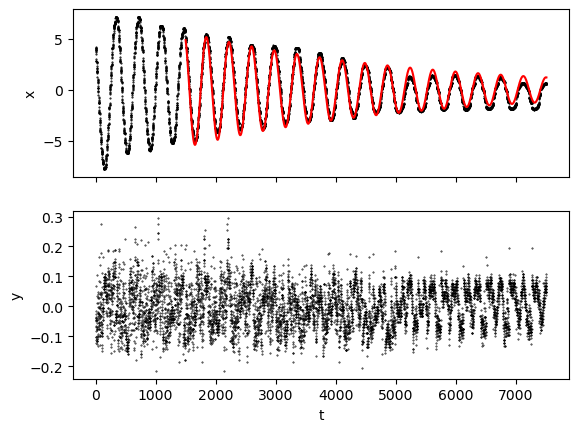

T_far =  377.24+/-0.04


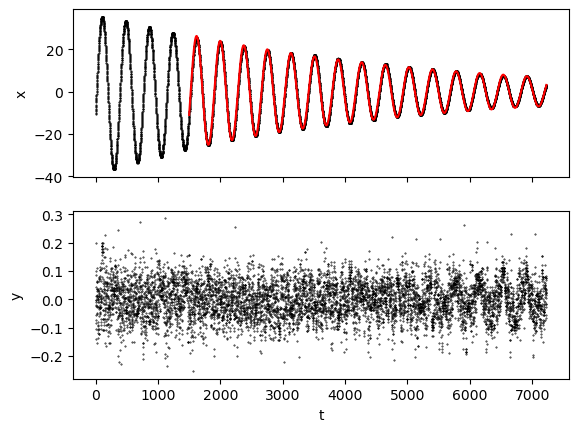

T_near =  378.236+/-0.007
G= (3.8+/-0.5)e-10


In [85]:
#new 2h meas Tn
cut1 = 1500
cut2 = -1
Tf2 =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_p02.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2, plot=True)[2]
wf2 = fit(*np.loadtxt('m9_tos/m9_p02.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2)[2]
print('T_far = ', Tf2)
Tn2 =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_n2.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2, plot=True)[2]
wn2 = fit(*np.loadtxt('m9_tos/m9_n2.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2)[2]
print('T_near = ', Tn2)
#new 2h meas Tn

# G tos

# laser meas
L =  unp.uarray(4.321, 0.001) #m
    
#measured:
M = unp.uarray(1.5,0.01) 
#technical drawing
m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

#I = m*l**2/2 #kg m^2, using MIT estimated formula
l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
#l=unp.uarray(0.12, 0.001)
rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
#I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
I = m*l**2/2



#values:
rm = l/2
rM = ufloat(0.146,0.002)
r = rM-rm



#calc
Cn = -M*m*(3 * rm**2 * rM**2 -r**2 * rm * rM)/r**5
#Cn = 2 * M * m * rm * rM / r**3


G = I * (wn2**2 - wf2**2) /Cn

print('G=',G)

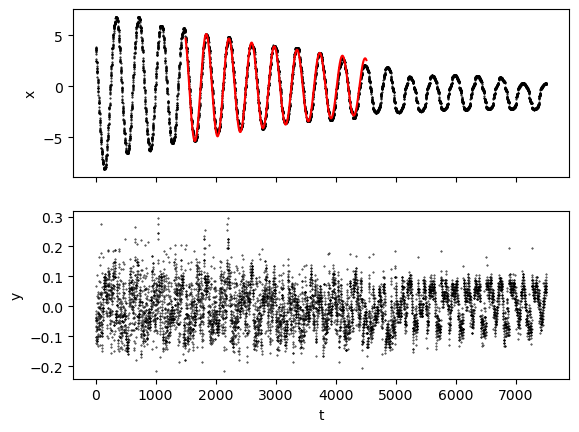

T_far =  378.15+/-0.04


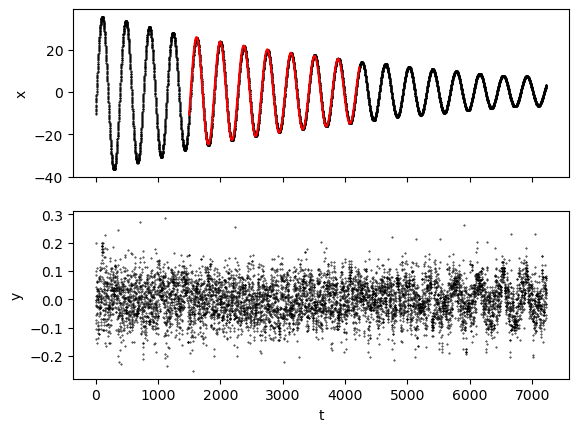

T_near =  378.322+/-0.012
G= (6.5+/-1.8)e-11


In [118]:
#new 2h meas Tn
cut1 = 1500
cut2 = -3000
Tf2 =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_p02.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2, plot=True)[2]
wf2 = fit(*np.loadtxt('m9_tos/m9_p02.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2)[2]
print('T_far = ', Tf2)
Tn2 =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_n2.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2, plot=True)[2]
wn2 = fit(*np.loadtxt('m9_tos/m9_n2.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2)[2]
print('T_near = ', Tn2)
#new 2h meas Tn

# G tos

# laser meas
L =  unp.uarray(4.321, 0.001) #m
    
#measured:
M = unp.uarray(1.5,0.01) 
#technical drawing
m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

#I = m*l**2/2 #kg m^2, using MIT estimated formula
l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
#l=unp.uarray(0.12, 0.001)
rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
#I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
I = m*l**2/2



#values:
rm = l/2
rM = ufloat(0.146,0.002)
r = rM-rm



#calc
Cn = -M*m*(3 * rm**2 * rM**2 -r**2 * rm * rM)/r**5
#Cn = 2 * M * m * rm * rM / r**3


G = I * (wn2**2 - wf2**2) /Cn

print('G=',G)

## Fourier trafo. for meas 2

0.002564102564102564
Tn2 =  390.0
0.002655160969133754
T02 =  376.625
G= (4.9+/-0.6)e-09


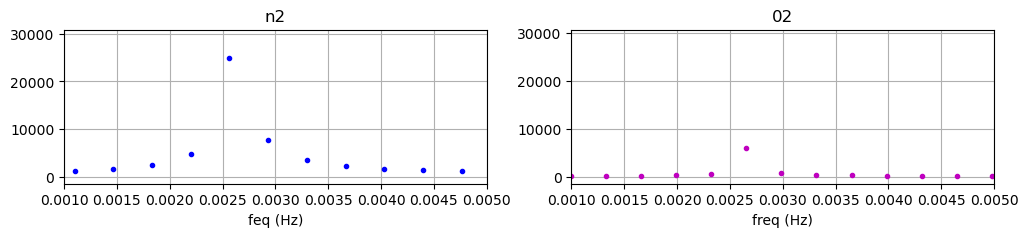

In [125]:
#n2
#cut1 = 1500
#cut2 = -1

cut1 = 1500
cut2 = -3000

dat_n2 = np.loadtxt('m9_tos/m9_n2.txt', skiprows=2, unpack=True)
dat_xy_n2 = rotate_data(dat_n2[1,:], dat_n2[2,:])
T_n2_fft = np.fft.fft(dat_xy_n2[0][cut1:cut2])
freqs_n2 = np.fft.fftfreq(len(T_n2_fft), d=1.0)  # d = sampling interval (1 s)

mask_n2 = freqs_n2 > 0
idx_max_n2 = np.argmax(np.abs(T_n2_fft[mask_n2]))
f_max_n2 = freqs_n2[mask_n2][idx_max_n2]
print(f_max_n2)
print('Tn2 = ',  1/f_max_n2)

dat_02 = np.loadtxt('m9_tos/m9_p02.txt', skiprows=2, unpack=True)
dat_xy_02 = rotate_data(dat_02[1,:], dat_02[2,:])
T_02_fft = np.fft.fft(dat_xy_02[0][cut1:cut2])
freqs_02 = np.fft.fftfreq(len(T_02_fft), d=1.0)  # d = sampling interval (1 s)

mask_02 = freqs_02 > 0
idx_max_02 = np.argmax(np.abs(T_02_fft[mask_02]))
f_max_02 = freqs_02[mask_02][idx_max_02]
print(f_max_02)
print('T02 = ',  1/f_max_02)

plt.figure(figsize=(12,2))
plt.subplot(121)
plt.title('n2')
plt.plot(freqs_n2, np.abs(T_n2_fft),'b.')
plt.xlabel("feq (Hz)")
plt.xlim(0.001,0.005)
plt.grid()
plt.subplot(122)
plt.title('02')
plt.plot(freqs_02, np.abs(T_02_fft),'m.')
plt.xlabel("freq (Hz)")
plt.xlim(0.001,0.005)
plt.grid()

wn2 = f_max_n2*(2*np.pi)
wf2 = f_max_02*(2*np.pi)

G = I * (wn2**2 - wf2**2) /Cn

print('G=',G)

0.0024939314335117877
Tn2 =  400.97333333333336
0.0023905144387072097
T02 =  418.32
G= (-5.2+/-0.6)e-09


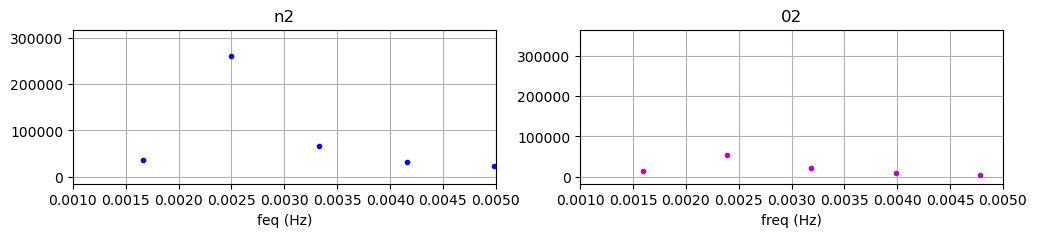

In [8]:
#n2

cut1 = 1
cut2 = -1

dat_n2 = np.loadtxt('m9_tos/m9_n2_40to60.txt', skiprows=2, unpack=True)
dat_xy_n2 = rotate_data(dat_n2[1,:], dat_n2[2,:])
T_n2_fft = np.fft.fft(dat_xy_n2[0][cut1:cut2])
freqs_n2 = np.fft.fftfreq(len(T_n2_fft), d=1/25 )  # d = sampling interval, adjust 25 fps

mask_n2 = freqs_n2 > 0
idx_max_n2 = np.argmax(np.abs(T_n2_fft[mask_n2]))
f_max_n2 = freqs_n2[mask_n2][idx_max_n2]
print(f_max_n2)
print('Tn2 = ',  1/f_max_n2)

dat_02 = np.loadtxt('m9_tos/m9_p02_40to60.txt', skiprows=2, unpack=True)
dat_xy_02 = rotate_data(dat_02[1,:], dat_02[2,:])
T_02_fft = np.fft.fft(dat_xy_02[0][cut1:cut2])
freqs_02 = np.fft.fftfreq(len(T_02_fft), d= 1/25)

mask_02 = freqs_02 > 0
idx_max_02 = np.argmax(np.abs(T_02_fft[mask_02]))
f_max_02 = freqs_02[mask_02][idx_max_02]
print(f_max_02)
print('T02 = ',  1/f_max_02)

plt.figure(figsize=(12,2))
plt.subplot(121)
plt.title('n2')
plt.plot(freqs_n2, np.abs(T_n2_fft),'b.')
plt.xlabel("feq (Hz)")
plt.xlim(0.001,0.005)
plt.grid()
plt.subplot(122)
plt.title('02')
plt.plot(freqs_02, np.abs(T_02_fft),'m.')
plt.xlabel("freq (Hz)")
plt.xlim(0.001,0.005)
plt.grid()

wn2 = f_max_n2*(2*np.pi)
wf2 = f_max_02*(2*np.pi)

G = I * (wn2**2 - wf2**2) /Cn

print('G=',G)

In [131]:
print(len(dat_xy_02[0][cut1:cut2]))
print(wn2**2 - wf2**2)
fake_fps = 25 #original vid resolution
print('resol: 1/fps/len', 1/fake_fps/len(dat_xy_02[0][cut1:cut2]))

3013
-1.876242640242359e-05
resol: 1/fps/len 1.3275804845668769e-05


## meas 3 tos, 3h before each meas 15 min static defl  

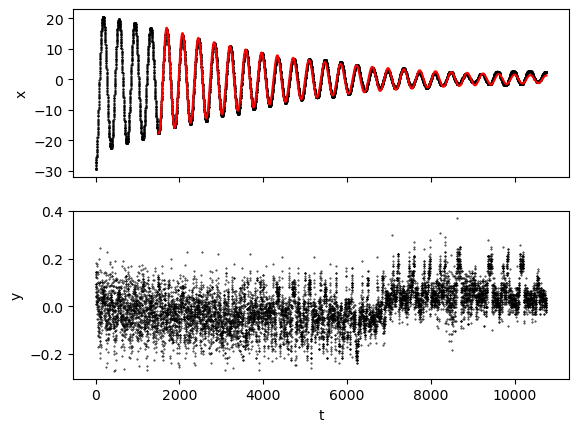

T_far =  377.315+/-0.020


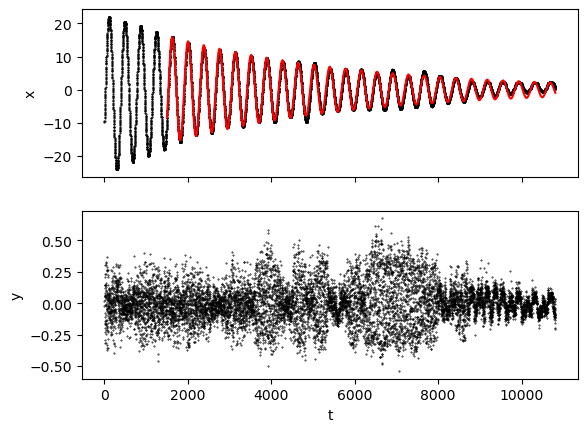

T_near =  377.424+/-0.014
G= (4.2+/-1.0)e-11


In [13]:
#new 2h meas Tn
cut1 = 1500
cut2 = -1
Tf2 =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_p03.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2, plot=True)[2]
wf2 = fit(*np.loadtxt('m9_tos/m9_p03.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2)[2]
print('T_far = ', Tf2)
Tn2 =  2*np.pi/fit(*np.loadtxt('m9_tos/m9_n3.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2, plot=True)[2]
wn2 = fit(*np.loadtxt('m9_tos/m9_n3.txt', skiprows=2, unpack=True), cutoff=cut1, cutoffend=cut2)[2]
print('T_near = ', Tn2)
#new 2h meas Tn

# G tos

# laser meas
L =  unp.uarray(4.321, 0.001) #m
    
#measured:
M = unp.uarray(1.5,0.01) 
#technical drawing
m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing

#I = m*l**2/2 #kg m^2, using MIT estimated formula
l=unp.uarray(0.12, 0.001)-unp.uarray(0.0171, 0.001)
#l=unp.uarray(0.12, 0.001)
rk = unp.uarray(0.0171,0.00001)# radius of pendulum spheres
#I = 2*m *( 2/5 * rk**2 + (l/2)**2)  #improvement of I
I = m*l**2/2



#values:
rm = l/2
rM = ufloat(0.146,0.002)
r = rM-rm



#calc
Cn = -M*m*(3 * rm**2 * rM**2 -r**2 * rm * rM)/r**5
#Cn = 2 * M * m * rm * rM / r**3


G = I * (wn2**2 - wf2**2) /Cn

print('G=',G)

## results TOS

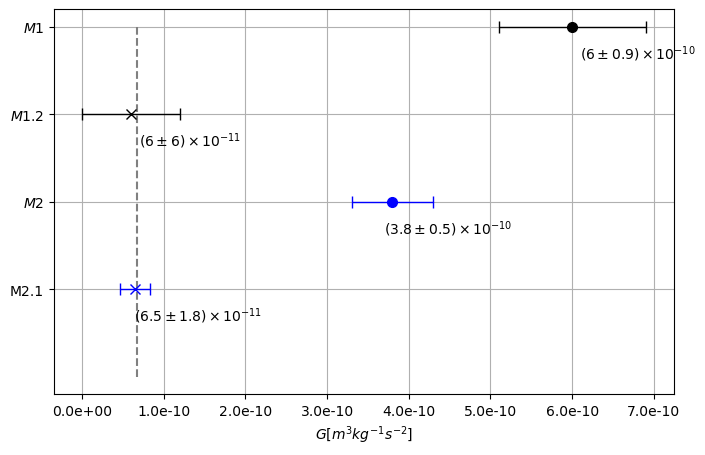

In [152]:
# plot for all results, incl errorbars
m1 = 6e-10
m1_err = 9e-11 

m1_2 = 6e-11
m1_2_err = 6e-11

m2_1 = 3.8e-10
m2_1_err = 0.5e-10

m2_2 = 6.5e-11
m2_2_err = 1.8e-11

plt.figure(figsize=(8,5))
y_pos = [6,5,4,3]

plt.errorbar(m1, 6, xerr=m1_err, fmt='ko', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5')

plt.errorbar(m1_2, 5, xerr=m1_2_err, fmt='kx', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m5_vac')

plt.errorbar(m2_1, 4, xerr=m2_1_err, fmt='bo', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m6')

plt.errorbar(m2_2, 3, xerr=m2_2_err, fmt='bx', capsize=4, elinewidth=1, markersize=7, linestyle='none', label='m6')

plt.vlines(6.67e-11,2,6, 'gray', label='literature', linestyle='dashed')
plt.xlabel('$G [m^3 kg^{-1} s^{-2}]$')
plt.yticks([])
from matplotlib.ticker import FormatStrFormatter
plt.gca().xaxis.set_major_formatter(FormatStrFormatter('%.1e'))
#plt.legend()

# Set y-axis labels instead of numbers
plt.yticks(y_pos, ['$M1$','$M1.2$','$M2$', 'M2.1'])
#plt.semilogx()
#plt.xlim(1e-9,1e-12)
plt.grid()

# ---- ADD VALUE LABELS ----
offset = 1e-11  # horizontal shift for text
off_down = 0.3
plt.text(m1 + offset, 6-off_down, r'$(6\pm0.9)\times10^{-10}$', va='center')
plt.text(m1_2 + offset, 5-off_down, r'$(6\pm6)\times10^{-11}$', va='center')
plt.text(m2_1 - offset, 4-off_down, r'$(3.8\pm0.5)\times10^{-10}$', va='center')
plt.text(m2_2 - 0.1*offset, 3-off_down, r'$(6.5\pm1.8)\times10^{-11}$', va='center')


plt.savefig('results_tos.png')